# EDA FD002 - condiciones operativas

Objetivo: entender como las seis condiciones operativas de FD002 afectan las mediciones de sensores y la relacion con RUL.

FD002 tiene un solo modo de falla, pero seis regimes operativos. Por eso la pregunta principal es si la baja correlacion global sensor-RUL se debe a mezclar distribuciones de sensores de condiciones distintas.


## 1. Setup


In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "CMAPSSData").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import FEATURE_COLUMNS, SENSOR_COLUMNS, SETTING_COLUMNS, add_train_rul, last_cycle_rows, load_cmapss_subset
from src.eda import correlation_with_target, dataset_overview, train_test_distribution_shift

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid")

FIGURES_DIR = PROJECT_ROOT / "figures" / "EDA"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42


## 2. Carga de FD002

FD002 combina seis condiciones operativas con un unico modo de falla. A diferencia de FD001, los settings no son ruido: definen regimes que afectan directamente los sensores.


In [2]:
data = load_cmapss_subset("FD002", data_dir=PROJECT_ROOT / "CMAPSSData")
train = add_train_rul(data.train)
test = data.test.copy()
test_last = last_cycle_rows(test).merge(data.rul, on="unit", how="left")

overview = dataset_overview(data.train, data.test, data.rul)
overview


,dataset,rows,columns,units,missing_values,duplicated_rows
0,train,53759,26,260,0,0
1,test,33991,26,259,0,0
2,rul,259,2,259,0,0


In [3]:
setting_summary = train[SETTING_COLUMNS].agg(["mean", "std", "min", "max"]).T
setting_summary


,mean,std,min,max
setting_1,23.9984,14.7474,0.0000,42.0080
setting_2,0.5721,0.3100,0.0000,0.8420
setting_3,94.0460,14.2377,60.0000,100.0000


## 3. Identificacion de las seis conditions

El dataset declara seis condiciones operativas. Se usa clustering no supervisado sobre `setting_1`, `setting_2` y `setting_3` para asignar un `condition_id` reproducible a cada fila.


In [4]:
settings_scaler = StandardScaler()
settings_X = settings_scaler.fit_transform(train[SETTING_COLUMNS])

# El silhouette es costoso en todas las filas; una muestra alcanza para validar k.
settings_sample = train[SETTING_COLUMNS].sample(
    min(12000, len(train)),
    random_state=RANDOM_STATE,
)
settings_sample_X = settings_scaler.transform(settings_sample)

k_rows = []
for k in range(2, 10):
    labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(settings_sample_X)
    k_rows.append({"k": k, "silhouette_sample": silhouette_score(settings_sample_X, labels)})

condition_k_summary = pd.DataFrame(k_rows)
condition_k_summary


,k,silhouette_sample
0,2,0.6190
1,3,0.8010
2,4,0.8512
3,5,0.9304
4,6,0.9971
5,7,0.9331
6,8,0.8987
7,9,0.8629


In [5]:
condition_model = KMeans(n_clusters=6, random_state=RANDOM_STATE, n_init=50)
train_raw_condition = condition_model.fit_predict(settings_X)

centers = pd.DataFrame(
    settings_scaler.inverse_transform(condition_model.cluster_centers_),
    columns=SETTING_COLUMNS,
)
centers["raw_condition"] = range(len(centers))
centers = centers.sort_values(SETTING_COLUMNS).reset_index(drop=True)
centers["condition_id"] = range(1, len(centers) + 1)
condition_mapping = dict(zip(centers["raw_condition"], centers["condition_id"]))

train_cond = train.copy()
train_cond["condition_id"] = pd.Series(train_raw_condition).map(condition_mapping).to_numpy()

test_raw_condition = condition_model.predict(settings_scaler.transform(test[SETTING_COLUMNS]))
test_cond = test.copy()
test_cond["condition_id"] = pd.Series(test_raw_condition).map(condition_mapping).to_numpy()

test_last_cond = last_cycle_rows(test_cond).merge(data.rul, on="unit", how="left")

centers[["condition_id"] + SETTING_COLUMNS]


,condition_id,setting_1,setting_2,setting_3
0,1,0.0015,0.0005,100.0000
1,2,10.0030,0.2505,100.0000
2,3,20.0030,0.7005,100.0000
3,4,25.0030,0.6205,60.0000
4,5,35.0030,0.8405,100.0000
5,6,42.0030,0.8405,100.0000


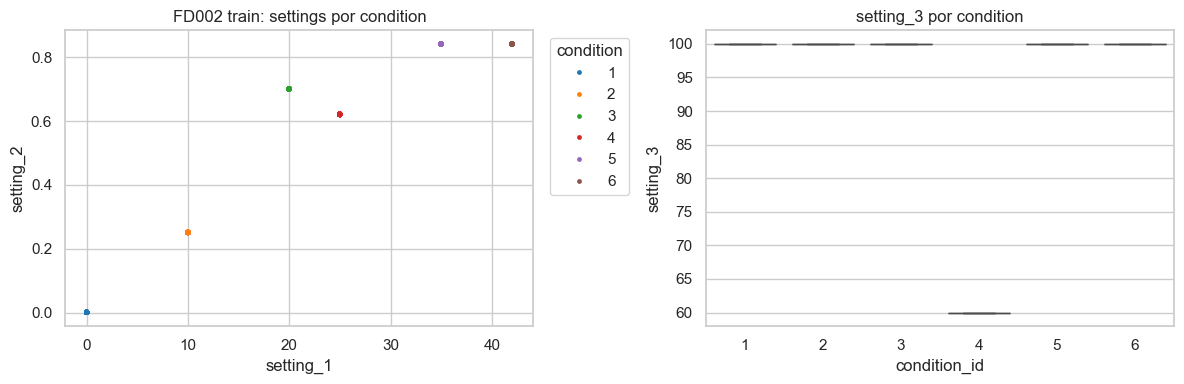

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(
    data=train_cond.sample(min(12000, len(train_cond)), random_state=RANDOM_STATE),
    x="setting_1",
    y="setting_2",
    hue="condition_id",
    palette="tab10",
    s=12,
    linewidth=0,
    ax=axes[0],
)
axes[0].set_title("FD002 train: settings por condition")
axes[0].legend(title="condition", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.boxplot(data=train_cond, x="condition_id", y="setting_3", ax=axes[1], showfliers=False)
axes[1].set_title("setting_3 por condition")
axes[1].set_xlabel("condition_id")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd002_conditions_settings_clusters.png", dpi=150)
plt.show()


## 4. Balance de conditions en train y test

Antes de modelar conviene ver si train y test tienen proporciones similares de conditions. Si no, el modelo puede enfrentar shift operativo.


In [7]:
def condition_distribution(df: pd.DataFrame, split: str) -> pd.DataFrame:
    counts = df["condition_id"].value_counts().sort_index()
    result = counts.rename("rows").reset_index().rename(columns={"index": "condition_id"})
    result["condition_id"] = result["condition_id"].astype(int)
    result["row_pct"] = result["rows"] / result["rows"].sum() * 100
    result["units"] = df.groupby("condition_id")["unit"].nunique().reindex(result["condition_id"]).to_numpy()
    result["split"] = split
    return result

condition_dist = pd.concat(
    [
        condition_distribution(train_cond, "train_rows"),
        condition_distribution(test_cond, "test_rows"),
        condition_distribution(test_last_cond, "test_last_cycle"),
    ],
    ignore_index=True,
)
condition_dist


,condition_id,rows,row_pct,units,split
0,1,8044,14.9631,260,train_rows
1,2,8096,15.0598,260,train_rows
2,3,8122,15.1082,260,train_rows
3,4,8002,14.8849,260,train_rows
4,5,8037,14.9501,260,train_rows
5,6,13458,25.0339,260,train_rows
6,1,5148,15.1452,259,test_rows
7,2,5107,15.0246,258,test_rows
8,3,5063,14.8951,259,test_rows
9,4,5042,14.8333,259,test_rows


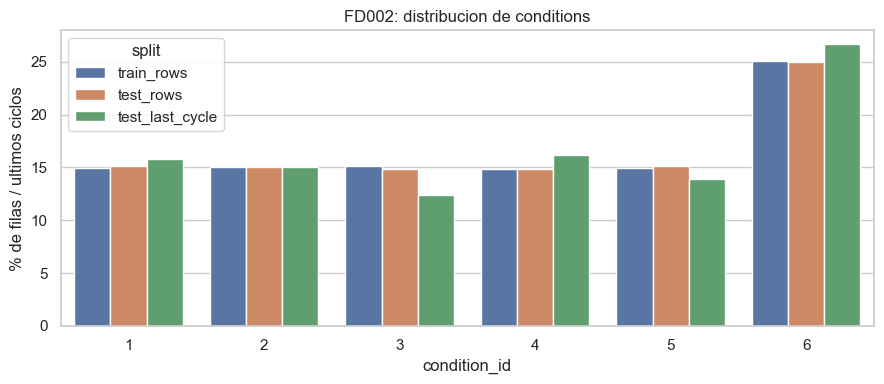

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=condition_dist, x="condition_id", y="row_pct", hue="split", ax=ax)
ax.set_title("FD002: distribucion de conditions")
ax.set_xlabel("condition_id")
ax.set_ylabel("% de filas / ultimos ciclos")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd002_condition_distribution.png", dpi=150)
plt.show()


In [9]:
unit_condition_counts = train_cond.groupby("unit")["condition_id"].nunique().describe()
unit_condition_counts


count   260.0000
mean      6.0000
std       0.0000
min       6.0000
25%       6.0000
50%       6.0000
75%       6.0000
max       6.0000
Name: condition_id, dtype: float64

## 5. Efecto de condition sobre sensores

Si los sensores cambian mucho entre conditions, una correlacion global sensor-RUL puede ser enganosa: estaria mezclando cambios por degradacion con cambios por regimen operativo.


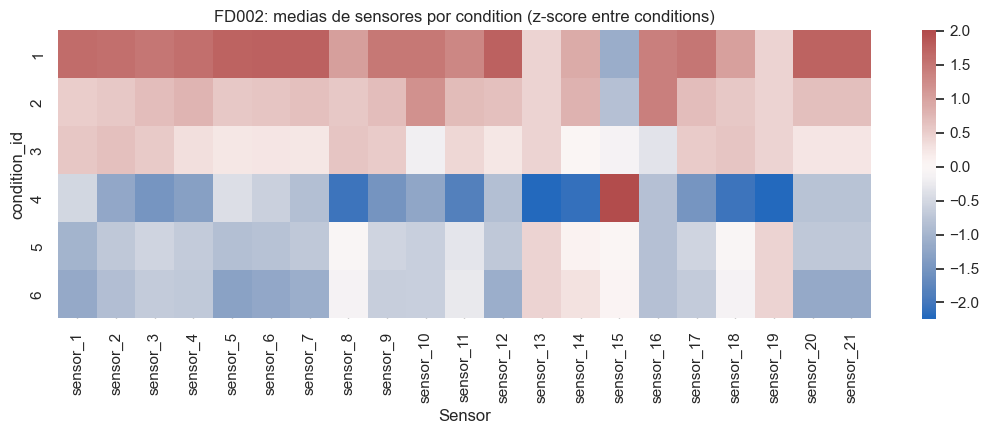

In [10]:
condition_sensor_means = train_cond.groupby("condition_id")[SENSOR_COLUMNS].mean()
condition_sensor_means_z = (condition_sensor_means - condition_sensor_means.mean()) / condition_sensor_means.std(ddof=0)

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.heatmap(condition_sensor_means_z, cmap="vlag", center=0, ax=ax)
ax.set_title("FD002: medias de sensores por condition (z-score entre conditions)")
ax.set_xlabel("Sensor")
ax.set_ylabel("condition_id")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd002_sensor_means_by_condition_heatmap.png", dpi=150)
plt.show()


In [11]:
pooled_sensor_std = train_cond[SENSOR_COLUMNS].std()
condition_sensor_effect = (
    (condition_sensor_means.max() - condition_sensor_means.min()) / pooled_sensor_std
).sort_values(ascending=False)
condition_sensor_effect.head(12).rename("condition_range_over_global_std").to_frame()


,condition_range_over_global_std
sensor_11,3.3228
sensor_15,3.2985
sensor_8,3.2552
sensor_18,3.2547
sensor_9,3.1188
sensor_14,3.1024
sensor_3,3.0934
sensor_17,3.0932
sensor_4,3.0098
sensor_5,2.9636


## 6. Correlacion sensor-RUL global vs dentro de condition

Se compara la correlacion global con la correlacion calculada por condition. Si dentro de conditions aparecen relaciones mas fuertes, entonces las conditions estaban ocultando parte de la senal.


In [12]:
global_corr = correlation_with_target(train_cond, target="RUL", columns=SENSOR_COLUMNS)

def corr_by_condition(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for condition_id, group in df.groupby("condition_id"):
        corr = correlation_with_target(group, target="RUL", columns=SENSOR_COLUMNS)
        for sensor, row in corr.iterrows():
            rows.append(
                {
                    "condition_id": condition_id,
                    "sensor": sensor,
                    "correlation": row["correlation"],
                    "abs_correlation": row["abs_correlation"],
                }
            )
    return pd.DataFrame(rows)

condition_corr = corr_by_condition(train_cond)
condition_corr_summary = (
    condition_corr.groupby("sensor")
    .agg(
        mean_abs_corr_by_condition=("abs_correlation", "mean"),
        max_abs_corr_by_condition=("abs_correlation", "max"),
    )
    .join(global_corr[["abs_correlation"]].rename(columns={"abs_correlation": "global_abs_corr"}))
)
condition_corr_summary["mean_abs_gain_vs_global"] = (
    condition_corr_summary["mean_abs_corr_by_condition"] - condition_corr_summary["global_abs_corr"]
)
condition_corr_summary.sort_values("mean_abs_gain_vs_global", ascending=False).head(12)


,mean_abs_corr_by_condition,max_abs_corr_by_condition,global_abs_corr,mean_abs_gain_vs_global
sensor,,,,
sensor_11,0.6934,0.7123,0.0469,0.6464
sensor_4,0.6619,0.6956,0.0410,0.6209
sensor_15,0.6555,0.6913,0.0385,0.6170
sensor_2,0.5664,0.6189,0.0049,0.5615
sensor_17,0.5782,0.6046,0.0270,0.5511
sensor_3,0.5548,0.5899,0.0269,0.5278
sensor_12,0.5068,0.6901,0.0022,0.5045
sensor_16,0.5508,0.5508,0.0714,0.4795
sensor_7,0.4799,0.6794,0.0024,0.4775


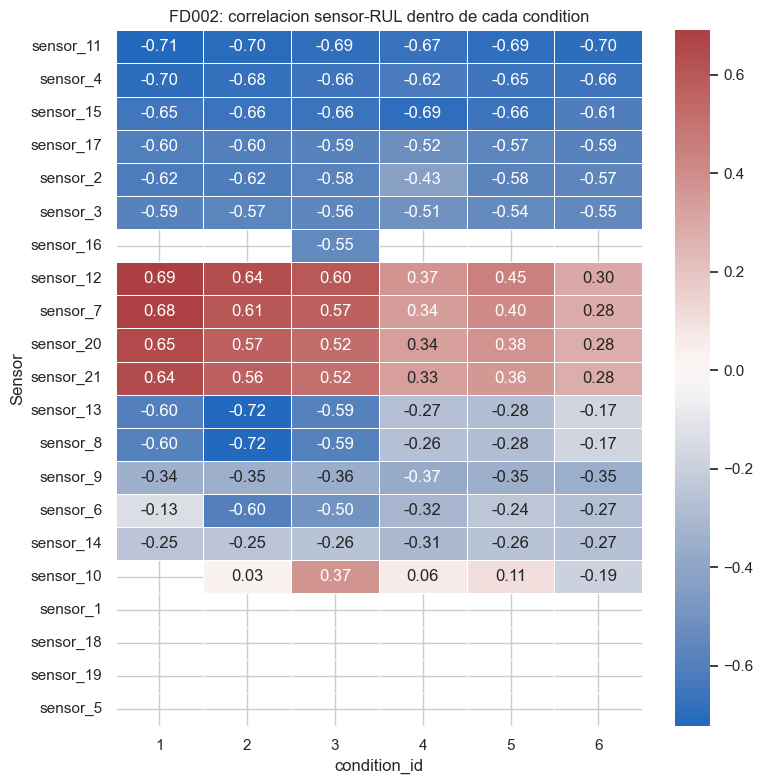

In [13]:
corr_heatmap = condition_corr.pivot(index="sensor", columns="condition_id", values="correlation")
ordered_sensors = corr_heatmap.abs().mean(axis=1).sort_values(ascending=False).index
corr_heatmap = corr_heatmap.loc[ordered_sensors]

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(corr_heatmap, cmap="vlag", center=0, annot=True, fmt=".2f", linewidths=0.4, ax=ax)
ax.set_title("FD002: correlacion sensor-RUL dentro de cada condition")
ax.set_xlabel("condition_id")
ax.set_ylabel("Sensor")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd002_sensor_rul_corr_by_condition_heatmap.png", dpi=150)
plt.show()


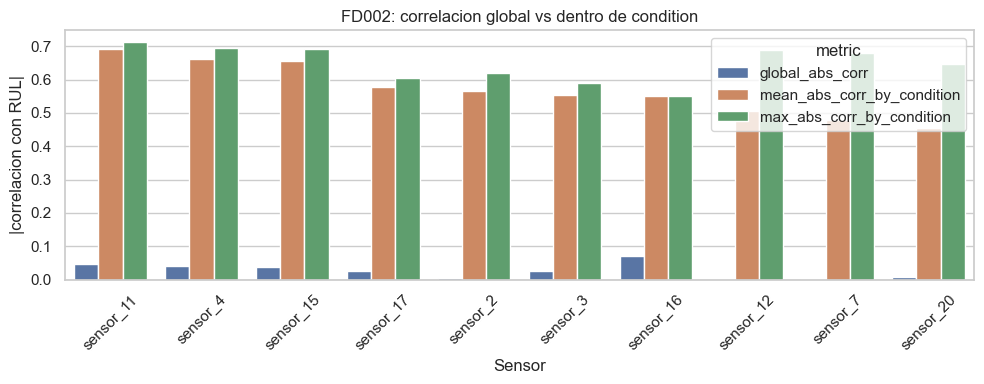

In [14]:
top_corr_compare = condition_corr_summary.sort_values("mean_abs_corr_by_condition", ascending=False).head(10).reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
plot_compare = top_corr_compare.melt(
    id_vars="sensor",
    value_vars=["global_abs_corr", "mean_abs_corr_by_condition", "max_abs_corr_by_condition"],
    var_name="metric",
    value_name="abs_corr",
)
sns.barplot(data=plot_compare, x="sensor", y="abs_corr", hue="metric", ax=ax)
ax.set_title("FD002: correlacion global vs dentro de condition")
ax.set_xlabel("Sensor")
ax.set_ylabel("|correlacion con RUL|")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd002_global_vs_condition_corr.png", dpi=150)
plt.show()


## 7. Normalizacion simple por condition

Como prueba rapida, se estandarizan sensores dentro de cada condition y se recalcula la correlacion global con RUL. Esto no reemplaza un pipeline de modelado, pero indica si normalizar por regimen puede recuperar senal.


In [15]:
train_cond_norm = train_cond.copy()
for sensor in SENSOR_COLUMNS:
    grouped = train_cond_norm.groupby("condition_id")[sensor]
    train_cond_norm[f"{sensor}_cond_z"] = (train_cond_norm[sensor] - grouped.transform("mean")) / grouped.transform("std")

condition_norm_cols = [f"{sensor}_cond_z" for sensor in SENSOR_COLUMNS]
condition_norm_corr = correlation_with_target(train_cond_norm, target="RUL", columns=condition_norm_cols)
condition_norm_corr.index = [index.replace("_cond_z", "") for index in condition_norm_corr.index]

norm_corr_compare = global_corr[["abs_correlation"]].rename(columns={"abs_correlation": "raw_global_abs_corr"}).join(
    condition_norm_corr[["abs_correlation"]].rename(columns={"abs_correlation": "condition_z_abs_corr"})
)
norm_corr_compare["gain"] = norm_corr_compare["condition_z_abs_corr"] - norm_corr_compare["raw_global_abs_corr"]
norm_corr_compare.sort_values("gain", ascending=False).head(12)


,raw_global_abs_corr,condition_z_abs_corr,gain
sensor_11,0.0469,0.6936,0.6467
sensor_4,0.0410,0.6619,0.6209
sensor_15,0.0385,0.6504,0.6119
sensor_2,0.0049,0.5671,0.5621
sensor_17,0.0270,0.5793,0.5523
sensor_3,0.0269,0.5549,0.5279
sensor_12,0.0022,0.4860,0.4838
sensor_16,0.0714,0.5508,0.4795
sensor_7,0.0024,0.4607,0.4583
sensor_20,0.0063,0.4375,0.4312


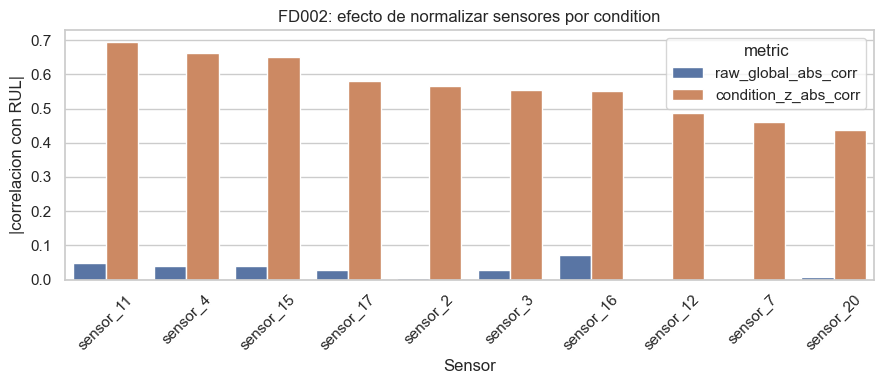

In [16]:
top_norm_compare = norm_corr_compare.sort_values("condition_z_abs_corr", ascending=False).head(10).reset_index().rename(columns={"index": "sensor"})
plot_norm = top_norm_compare.melt(
    id_vars="sensor",
    value_vars=["raw_global_abs_corr", "condition_z_abs_corr"],
    var_name="metric",
    value_name="abs_corr",
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=plot_norm, x="sensor", y="abs_corr", hue="metric", ax=ax)
ax.set_title("FD002: efecto de normalizar sensores por condition")
ax.set_xlabel("Sensor")
ax.set_ylabel("|correlacion con RUL|")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd002_condition_normalized_corr.png", dpi=150)
plt.show()


## 8. PCA + clustering de firmas de degradacion

FD002 tiene seis conditions operativas, asi que en esta visualizacion se fuerza `k=6` para mantener la lectura alineada con las seis condiciones evaluadas. Como cada motor recorre las seis conditions, esta no es una etiqueta de condition por motor: es una particion exploratoria de firmas de degradacion calculadas con sensores normalizados por `condition_id`.

La tabla de silhouette para `k=2..6` queda como diagnostico: si `k=2` separa mejor, eso no significa que FD002 tenga dos conditions, sino que las firmas residuales por motor tienen una division mas gruesa que las seis condiciones operativas.

In [17]:
train_cond_norm_cluster = train_cond_norm.copy()
train_cond_norm_cluster[condition_norm_cols] = (
    train_cond_norm_cluster[condition_norm_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0.0)
)


def unit_degradation_signature(df: pd.DataFrame, sensor_cols: list[str]) -> pd.DataFrame:
    rows = []
    for unit, group in df.sort_values(["unit", "cycle"]).groupby("unit"):
        life_cycles = group["cycle"].max()
        first_window = group.head(min(5, len(group)))
        last_window = group.tail(min(5, len(group)))

        row = {"unit": unit, "life_cycles": life_cycles}
        for column in sensor_cols:
            sensor_name = column.replace("_cond_z", "")
            start = first_window[column].mean()
            end = last_window[column].mean()
            row[f"{sensor_name}_start"] = start
            row[f"{sensor_name}_end"] = end
            row[f"{sensor_name}_delta"] = end - start
            row[f"{sensor_name}_slope"] = (end - start) / life_cycles

        condition_mix = group["condition_id"].value_counts(normalize=True).reindex(range(1, 7), fill_value=0)
        for condition_id, share in condition_mix.items():
            row[f"condition_{condition_id}_share"] = share

        rows.append(row)

    return pd.DataFrame(rows)


signature_norm = unit_degradation_signature(train_cond_norm_cluster, condition_norm_cols)
signature_norm.head()

,unit,life_cycles,sensor_1_start,sensor_1_end,sensor_1_delta,sensor_1_slope,sensor_2_start,sensor_2_end,sensor_2_delta,sensor_2_slope,sensor_3_start,sensor_3_end,sensor_3_delta,sensor_3_slope,sensor_4_start,sensor_4_end,sensor_4_delta,sensor_4_slope,sensor_5_start,sensor_5_end,sensor_5_delta,sensor_5_slope,sensor_6_start,sensor_6_end,sensor_6_delta,sensor_6_slope,sensor_7_start,sensor_7_end,sensor_7_delta,sensor_7_slope,sensor_8_start,sensor_8_end,sensor_8_delta,sensor_8_slope,sensor_9_start,sensor_9_end,sensor_9_delta,sensor_9_slope,sensor_10_start,sensor_10_end,sensor_10_delta,sensor_10_slope,sensor_11_start,sensor_11_end,sensor_11_delta,sensor_11_slope,sensor_12_start,sensor_12_end,sensor_12_delta,sensor_12_slope,sensor_13_start,sensor_13_end,sensor_13_delta,sensor_13_slope,sensor_14_start,sensor_14_end,sensor_14_delta,sensor_14_slope,sensor_15_start,sensor_15_end,sensor_15_delta,sensor_15_slope,sensor_16_start,sensor_16_end,sensor_16_delta,sensor_16_slope,sensor_17_start,sensor_17_end,sensor_17_delta,sensor_17_slope,sensor_18_start,sensor_18_end,sensor_18_delta,sensor_18_slope,sensor_19_start,sensor_19_end,sensor_19_delta,sensor_19_slope,sensor_20_start,sensor_20_end,sensor_20_delta,sensor_20_slope,sensor_21_start,sensor_21_end,sensor_21_delta,sensor_21_slope,condition_1_share,condition_2_share,condition_3_share,condition_4_share,condition_5_share,condition_6_share
0,1,149,0.0000,0.0000,0.0000,0.0000,0.1450,1.9339,1.7890,0.0120,-0.7609,1.8096,2.5705,0.0173,-0.0908,2.0913,2.1821,0.0146,0.0000,0.0000,0.0000,0.0000,-0.7729,0.1474,0.9203,0.0062,-0.0909,-2.0004,-1.9094,-0.0128,-1.2833,0.2036,1.4869,0.0100,-1.2140,-1.0364,0.1776,0.0012,-0.0680,-0.0503,0.0177,0.0001,-0.1043,2.4159,2.5202,0.0169,-0.3138,-1.6078,-1.2940,-0.0087,-1.2268,0.2473,1.4741,0.0099,-1.2392,-1.3348,-0.0955,-0.0006,-0.2075,2.0923,2.2998,0.0154,0.0000,0.0000,0.0000,0.0000,0.0328,1.8877,1.8549,0.0124,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-1.0617,-1.1209,-0.0592,-0.0004,0.0893,-1.7445,-1.8338,-0.0123,0.1611,0.1208,0.1342,0.1477,0.1477,0.2886
1,2,269,0.0000,0.0000,0.0000,0.0000,-0.1454,1.4692,1.6146,0.0060,-0.5742,2.0868,2.6611,0.0099,-0.5039,2.1588,2.6627,0.0099,0.0000,0.0000,0.0000,0.0000,-0.1932,0.6952,0.8884,0.0033,0.0795,-1.4506,-1.5301,-0.0057,-0.4533,1.4561,1.9095,0.0071,-0.0844,1.7136,1.7981,0.0067,-0.0720,0.0078,0.0798,0.0003,-0.5529,2.1508,2.7037,0.0101,-0.0871,-2.1204,-2.0333,-0.0076,-0.1546,1.3831,1.5376,0.0057,0.1406,1.3288,1.1882,0.0044,-0.3878,2.1662,2.5540,0.0095,0.0000,0.0000,0.0000,0.0000,-0.3841,1.7623,2.1465,0.0080,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4364,-1.1849,-1.6213,-0.0060,0.1826,-1.3864,-1.5690,-0.0058,0.1413,0.1338,0.1636,0.1561,0.1524,0.2528
2,3,206,0.0000,0.0000,0.0000,0.0000,-0.8054,1.7147,2.5201,0.0122,-0.8398,1.3015,2.1413,0.0104,-0.5453,2.0386,2.5839,0.0125,0.0000,0.0000,0.0000,0.0000,-1.0550,0.4099,1.4648,0.0071,1.0174,-1.5253,-2.5427,-0.0123,-0.3076,0.6379,0.9455,0.0046,-0.2395,0.2030,0.4425,0.0021,0.1656,-0.4233,-0.5889,-0.0029,-0.7369,1.8610,2.5979,0.0126,0.6322,-1.6412,-2.2734,-0.0110,-0.3989,0.5687,0.9675,0.0047,-0.2657,-0.2337,0.0320,0.0002,-0.9875,2.5660,3.5535,0.0172,-0.1044,0.3830,0.4874,0.0024,-0.4423,2.1302,2.5725,0.0125,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.8560,-1.2276,-2.0837,-0.0101,1.0651,-1.0488,-2.1139,-0.0103,0.1165,0.1505,0.1748,0.1359,0.1796,0.2427
3,4,235,0.0000,0.0000,0.0000,0.0000,-1.0315,2.2777,3.3092,0.0141,-0.7659,2.0165,2.7824,0.0118,-0.7525,1.7212,2.4737,0.0105,0.0000,0.0000,0.0000,0.0000,-0.5586,0.9101,1.4687,0.0062,0.4304,-1.7162,-2.1466,-0.0091,-0.3270,1.8203,2.1472,0.0091,-0.2741,4.5031,4.7771,0.0203,0.0134,0.0116,-0.0018,-0.0000,-0.6524,2.3578,3.0102,0.0128,0.0337,-1.5247,-1.5584,-0.0066,-0.4325,1.8340,2.2665,0.0096,-0.1488,4.4924,4.6412,0.0197,-0.6020,2.5077,3.1096,0.0132,-0.1044,0.0000,0.1044,0.0004,-0.6642,2.3291,2.9934,0.0127,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1817,-2.1976,-2.3793,-0.0101,0.1435,-2.1318,-2.275

In [18]:
sensor_signature_cols = [
    column
    for column in signature_norm.columns
    if column.endswith("_end") or column.endswith("_delta") or column.endswith("_slope")
]

X_signature = StandardScaler().fit_transform(signature_norm[sensor_signature_cols])
unit_cluster_k_rows = []
for k in range(2, 7):
    labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=30).fit_predict(X_signature)
    unit_cluster_k_rows.append({"k": k, "silhouette": silhouette_score(X_signature, labels)})

unit_cluster_k_summary = pd.DataFrame(unit_cluster_k_rows)
expected_condition_count = 6
selected_cluster_k = expected_condition_count
unit_cluster_k_summary["selected_for_plot"] = unit_cluster_k_summary["k"] == selected_cluster_k

unit_cluster_model = KMeans(n_clusters=selected_cluster_k, random_state=RANDOM_STATE, n_init=30)
degradation_cluster = unit_cluster_model.fit_predict(X_signature)
signature_norm["degradation_cluster"] = degradation_cluster
selected_silhouette = silhouette_score(X_signature, degradation_cluster)

condition_share_cols = [
    column
    for column in signature_norm.columns
    if column.startswith("condition_") and column.endswith("_share")
]
unit_cluster_summary = (
    signature_norm.groupby("degradation_cluster")
    .agg(
        units=("unit", "count"),
        life_cycles_mean=("life_cycles", "mean"),
        life_cycles_median=("life_cycles", "median"),
        **{column: (column, "mean") for column in condition_share_cols},
    )
    .reset_index()
)
unit_cluster_summary["silhouette_k6"] = selected_silhouette

display(unit_cluster_k_summary)
unit_cluster_summary

,k,silhouette,selected_for_plot
0,2,0.2400,False
1,3,0.1488,False
2,4,0.1359,False
3,5,0.1073,False
4,6,0.1060,True


,degradation_cluster,units,life_cycles_mean,life_cycles_median,condition_1_share,condition_2_share,condition_3_share,condition_4_share,condition_5_share,condition_6_share,silhouette_k6
0,0,56,217.7679,205.0000,0.1505,0.1493,0.1467,0.1551,0.1489,0.2495,0.1060
1,1,48,165.0000,159.0000,0.1500,0.1508,0.1511,0.1444,0.1534,0.2503,0.1060
2,2,34,229.1765,224.0000,0.1504,0.1530,0.1484,0.1487,0.1495,0.2501,0.1060
3,3,37,212.4324,202.0000,0.1504,0.1470,0.1551,0.1486,0.1508,0.2480,0.1060
4,4,83,212.0843,200.0000,0.1486,0.1516,0.1536,0.1476,0.1483,0.2504,0.1060
5,5,2,194.5000,194.5000,0.1569,0.1514,0.1393,0.1416,0.1360,0.2748,0.1060


In [19]:
cluster_feature_means = signature_norm.groupby("degradation_cluster")[sensor_signature_cols].mean()
top_cluster_gaps = (
    (cluster_feature_means.max() - cluster_feature_means.min())
    .sort_values(ascending=False)
    .head(12)
    .reset_index()
)
top_cluster_gaps.columns = ["feature", "range_across_clusters"]
top_cluster_gaps["sensor"] = top_cluster_gaps["feature"].str.extract(r"^(sensor_\d+)_")[0]
key_sensors_fd002 = top_cluster_gaps["sensor"].dropna().drop_duplicates().head(3).tolist()
top_cluster_gaps

,feature,range_across_clusters,sensor
0,sensor_10_end,11.8438,sensor_10
1,sensor_10_delta,11.6235,sensor_10
2,sensor_14_delta,6.6629,sensor_14
3,sensor_9_delta,6.6546,sensor_9
4,sensor_14_end,6.4835,sensor_14
5,sensor_9_end,6.3131,sensor_9
6,sensor_8_delta,3.6297,sensor_8
7,sensor_13_delta,3.6279,sensor_13
8,sensor_13_end,3.5810,sensor_13
9,sensor_8_end,3.5574,sensor_8


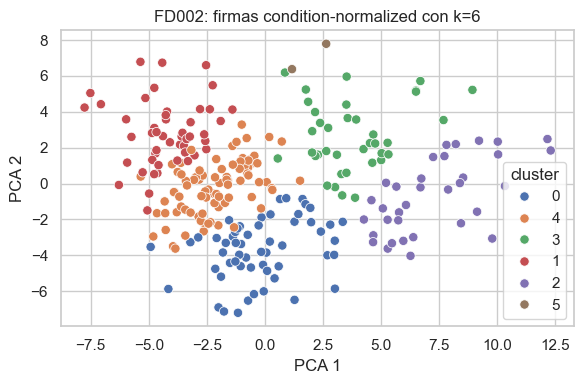

In [20]:
pca_model = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca_model.fit_transform(X_signature)
pca_plot = pd.DataFrame(pca_coords, columns=["pc1", "pc2"])
pca_plot["cluster"] = degradation_cluster.astype(str)
pca_plot["life_cycles"] = signature_norm["life_cycles"].to_numpy()

fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=pca_plot, x="pc1", y="pc2", hue="cluster", ax=ax, s=45)
ax.set_title("FD002: firmas condition-normalized con k=6")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.legend(title="cluster")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd002_condition_normalized_degradation_clusters_pca.png", dpi=150)
plt.show()

## 9. Trayectorias promedio por cluster

Para verificar si los grupos tienen una dinamica temporal distinta, se grafican las trayectorias promedio de los sensores que mas separan los clusters. Se usa vida normalizada para poder comparar motores con distinta duracion.

In [21]:
clustered_train_norm = train_cond_norm_cluster.merge(
    signature_norm[["unit", "degradation_cluster"]],
    on="unit",
    how="left",
)
clustered_train_norm["max_cycle"] = clustered_train_norm.groupby("unit")["cycle"].transform("max")
clustered_train_norm["life_pct"] = clustered_train_norm["cycle"] / clustered_train_norm["max_cycle"]
clustered_train_norm["life_bin"] = pd.cut(
    clustered_train_norm["life_pct"],
    bins=np.linspace(0, 1, 21),
    include_lowest=True,
    labels=False,
)
clustered_train_norm["life_bin_mid"] = (clustered_train_norm["life_bin"] + 0.5) / 20

key_sensor_norm_cols = [f"{sensor}_cond_z" for sensor in key_sensors_fd002]
cluster_trajectories = (
    clustered_train_norm.groupby(["degradation_cluster", "life_bin_mid"], as_index=False)[key_sensor_norm_cols]
    .mean()
)
cluster_trajectories.head()

,degradation_cluster,life_bin_mid,sensor_10_cond_z,sensor_14_cond_z,sensor_9_cond_z
0,0,0.0250,0.0127,-0.5463,-0.5599
1,0,0.0750,-0.0566,-0.5510,-0.5550
2,0,0.1250,-0.0063,-0.5456,-0.5420
3,0,0.1750,0.0061,-0.5202,-0.5372
4,0,0.2250,0.0006,-0.5108,-0.5269


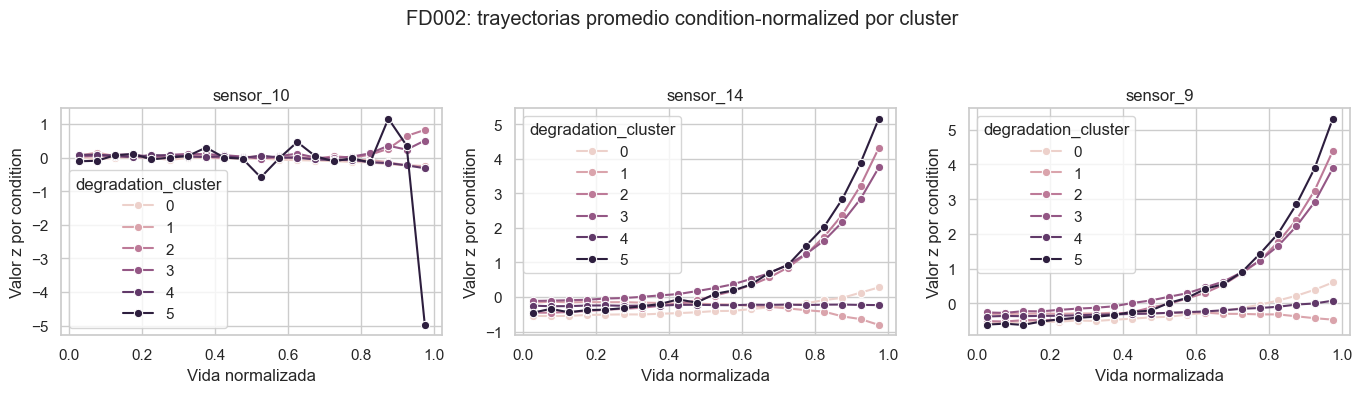

In [22]:
fig, axes = plt.subplots(1, len(key_sensors_fd002), figsize=(4.6 * len(key_sensors_fd002), 4), sharex=True)
if len(key_sensors_fd002) == 1:
    axes = [axes]

for ax, sensor, sensor_norm in zip(axes, key_sensors_fd002, key_sensor_norm_cols):
    sns.lineplot(
        data=cluster_trajectories,
        x="life_bin_mid",
        y=sensor_norm,
        hue="degradation_cluster",
        marker="o",
        ax=ax,
    )
    ax.set_title(sensor)
    ax.set_xlabel("Vida normalizada")
    ax.set_ylabel("Valor z por condition")

fig.suptitle("FD002: trayectorias promedio condition-normalized por cluster", y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig(FIGURES_DIR / "fd002_condition_normalized_cluster_sensor_trajectories.png", dpi=150)
plt.show()

## 10. Control: clustering sin slopes

Como en FD003, se repite el clustering quitando slopes. Se mantiene `k=6` para que el control sea comparable con las seis conditions, y la tabla de silhouette queda como diagnostico adicional.

In [23]:
no_slope_cols = [
    column
    for column in signature_norm.columns
    if column.endswith("_end") or column.endswith("_delta")
]

X_no_slope = StandardScaler().fit_transform(signature_norm[no_slope_cols])
no_slope_k_rows = []
for k in range(2, 7):
    labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=30).fit_predict(X_no_slope)
    no_slope_k_rows.append({"k": k, "silhouette": silhouette_score(X_no_slope, labels)})

no_slope_k_summary = pd.DataFrame(no_slope_k_rows)
selected_no_slope_k = expected_condition_count
no_slope_k_summary["selected_for_plot"] = no_slope_k_summary["k"] == selected_no_slope_k

cluster_no_slope = KMeans(n_clusters=selected_no_slope_k, random_state=RANDOM_STATE, n_init=30).fit_predict(X_no_slope)
silhouette_no_slope = silhouette_score(X_no_slope, cluster_no_slope)

signature_no_slope = signature_norm.copy()
signature_no_slope["cluster_no_slope"] = cluster_no_slope

no_slope_summary = (
    signature_no_slope.groupby("cluster_no_slope")
    .agg(
        units=("unit", "count"),
        life_cycles_mean=("life_cycles", "mean"),
        life_cycles_median=("life_cycles", "median"),
        **{column: (column, "mean") for column in condition_share_cols},
    )
    .reset_index()
)
no_slope_summary["silhouette_k6"] = silhouette_no_slope

display(no_slope_k_summary)
no_slope_summary

,k,silhouette,selected_for_plot
0,2,0.2548,False
1,3,0.1404,False
2,4,0.1279,False
3,5,0.1208,False
4,6,0.1272,True


,cluster_no_slope,units,life_cycles_mean,life_cycles_median,condition_1_share,condition_2_share,condition_3_share,condition_4_share,condition_5_share,condition_6_share,silhouette_k6
0,0,104,200.1250,194.0000,0.1504,0.1521,0.1514,0.1459,0.1503,0.2500,0.1272
1,1,33,214.2121,209.0000,0.1463,0.1546,0.1501,0.1549,0.1489,0.2452,0.1272
2,2,32,227.4688,216.0000,0.1519,0.1460,0.1541,0.1485,0.1511,0.2483,0.1272
3,3,66,194.2121,188.0000,0.1492,0.1486,0.1507,0.1510,0.1499,0.2506,0.1272
4,4,2,194.5000,194.5000,0.1569,0.1514,0.1393,0.1416,0.1360,0.2748,0.1272
5,5,23,234.3913,222.0000,0.1506,0.1489,0.1491,0.1484,0.1479,0.2551,0.1272


In [24]:
no_slope_feature_means = signature_no_slope.groupby("cluster_no_slope")[no_slope_cols].mean()
no_slope_top_gaps = (
    (no_slope_feature_means.max() - no_slope_feature_means.min())
    .sort_values(ascending=False)
    .head(12)
    .reset_index()
)
no_slope_top_gaps.columns = ["feature", "range_across_clusters"]
no_slope_top_gaps["sensor"] = no_slope_top_gaps["feature"].str.extract(r"^(sensor_\d+)_")[0]
no_slope_top_gaps

,feature,range_across_clusters,sensor
0,sensor_10_end,12.4493,sensor_10
1,sensor_10_delta,12.1971,sensor_10
2,sensor_14_end,6.2802,sensor_14
3,sensor_14_delta,6.1941,sensor_14
4,sensor_9_delta,6.1787,sensor_9
5,sensor_9_end,6.1048,sensor_9
6,sensor_8_delta,4.5155,sensor_8
7,sensor_13_delta,4.5080,sensor_13
8,sensor_13_end,4.3580,sensor_13
9,sensor_8_end,4.3310,sensor_8


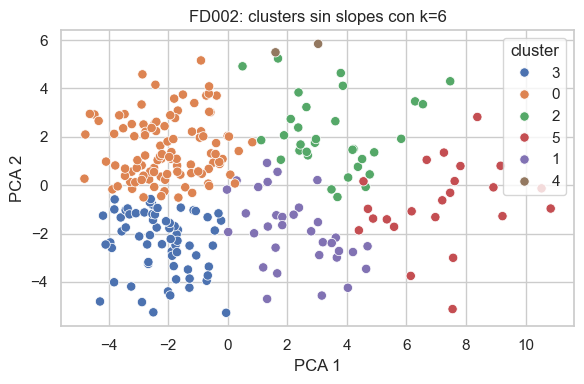

In [25]:
no_slope_pca = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_no_slope)
no_slope_pca = pd.DataFrame(no_slope_pca, columns=["pc1", "pc2"])
no_slope_pca["cluster"] = cluster_no_slope.astype(str)

fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=no_slope_pca, x="pc1", y="pc2", hue="cluster", ax=ax, s=45)
ax.set_title("FD002: clusters sin slopes con k=6")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.legend(title="cluster")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd002_condition_normalized_cluster_no_slope_pca.png", dpi=150)
plt.show()

## 11. Lectura final

- Los settings separan FD002 en seis conditions de forma muy clara. En la muestra usada para validar `k`, el silhouette de `k=6` es aproximadamente 0.997.
- Cada motor de train recorre las seis conditions. Por eso FD002 no es separable por motor-condition de forma simple: el regimen cambia dentro de las trayectorias.
- Train y test tienen proporciones muy parecidas por condition a nivel fila. La condition 6 aparece mas que las demas, cerca de 25% de las filas; las otras quedan alrededor de 15% cada una.
- Los sensores cambian mucho por condition. Los mas afectados por regimen son `sensor_11`, `sensor_15`, `sensor_8`, `sensor_18`, `sensor_9`, `sensor_14`, `sensor_3`, `sensor_17`, `sensor_4` y `sensor_5`.
- La correlacion global sensor-RUL subestima la senal. Por ejemplo, `sensor_11` tiene correlacion global absoluta cercana a 0.047, pero dentro de condition promedia aproximadamente 0.693.
- Al normalizar sensores por condition, reaparecen correlaciones fuertes con RUL: `sensor_11`, `sensor_4`, `sensor_15`, `sensor_2`, `sensor_17` y `sensor_3` pasan a ser claramente informativos.
- El PCA + clustering de firmas condition-normalized se muestra con `k=6` porque FD002 tiene seis conditions evaluadas. La silhouette de esa particion es baja/moderada, cerca de 0.106, y sube a cerca de 0.127 en el control sin slopes.
- Si se deja que silhouette elija `k`, aparece `k=2` como particion mas fuerte, con silhouette cercana a 0.240 y 0.255 sin slopes. Eso no contradice las seis conditions: solo indica que la firma residual por motor se agrupa en una separacion mas gruesa.
- Los clusters con `k=6` tienen mezcla de conditions parecida entre si, porque casi todos los motores recorren los seis regimes. Por eso no deben leerse como etiquetas directas de condition.
- Para modelado FD002 conviene incluir `condition_id` o normalizar sensores por condition. Un baseline que ignore conditions seria metodologicamente debil.
- Como FD002 tiene un solo modo de falla, el foco no es separar fault modes sino separar regimen operativo de degradacion.
